# Chapter 5.1 — Coupling & Conduction Speed

This is the first of four short notebooks that make up the **capstone** of the series. Chapter 2
turned one knob at a time on a single *cell* and watched the action-potential *shape* change. These
notebooks do exactly the same thing, but on a strip of *tissue*, watching the travelling *wave*
change. No optimiser, no fitting — you turn a knob, run, and read the effect off the wave. That is
what "tuning by hand" means, and it is how every serious model gets dialled in before any automation
is let near it.

This first notebook is about **how fast the wave goes** and the handful of knobs that set it:
conductivity **σ**, the diffusion constant **D**, and the two numbers hiding underneath them —
the surface-to-volume ratio **χ** and the membrane capacitance **Cm**.

**What you'll learn**

1. **Conductivity σ sets the speed** — and it does so as a *square root*: halving σ does **not** halve
   the conduction velocity.
2. **One number underneath: `D_eff = σ / (χ·Cm)`** — the single quantity the wave actually feels.
3. **χ and Cm are the denominators** — raising either one *slows* the wave, exactly as lowering σ does.
4. **The degeneracy** — because they all collapse into `D_eff`, different (σ, χ) pairs can give the
   *identical* wave. Four knobs, one effect.

**Runtime**: well under a minute (each measurement is a short tissue run). On Colab add ~a minute the
first time for the install.

In [1]:
# Installs cardiac_core if this environment doesn't already have it (e.g. a fresh Colab runtime).
# If it is already installed, this does nothing.
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("cardiac_core") is None:
    print("Installing cardiac_core - this takes about a minute, please wait...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "cardiac-core[viz] @ git+https://github.com/Zimmerman-Research-Group/CardiacCore.git"],
        check=True,
    )
    print("Installed.")
else:
    print("cardiac_core is already available.")

cardiac_core is already available.


In [2]:
import cardiac_core as cc
import matplotlib.pyplot as plt   # only used to plot the numbers we measure

print("cardiac_core is ready")

cardiac_core is ready


---
## 1. Conductivity σ — the speed knob

We measure conduction velocity the same way all through this notebook: build a thin strip of tissue,
fire an electrode along its left edge, let the wave cross, and ask the result for the velocity with
`r.cv(...)`. The only thing we will change from run to run is the **conductivity σ** — how freely the
tissue passes current from each patch to its neighbour.

The helper below packages that one measurement. `ConductivityConfig.bidomain(sigma_i, sigma_e)` sets
the intra- and extra-cellular conductivities (healthy human ventricle is `1.74, 6.25` mS/cm); we scale
*both* by a factor `k` to make the tissue a better or worse conductor. A strong stimulus
(`amplitude=-80`) guarantees the wave launches every time, so the only thing moving the velocity is σ.

In [3]:
def measure_cv(k=1.0):
    """Conduction velocity (cm/s) of a strip whose conductivity is k times healthy."""
    g    = cc.Grid(101, 31, 0.01)                                  # 1.0 cm x 0.3 cm strip
    cond = cc.ConductivityConfig.bidomain(1.74 * k, 6.25 * k)      # scale both sigmas by k
    stim = cc.Stim.boundary(g, "left", start_time=1.0, duration=2.0, amplitude=-80.0)
    sim  = cc.monodomain(g, "ttp06", cond, stim, dt=0.1)
    r    = sim.run(t_end=35.0, save_every=0.5)
    return cond, r.cv(x1=20, x2=70, y=15)                          # CV between two interior columns

factors = [0.5, 1.0, 2.0]                    # half, healthy, and double conductivity
results = [measure_cv(k) for k in factors]

for k, (cond, cv) in zip(factors, results):
    print(f"sigma x {k:>3}:  sigma_eff = {cond.sigma_eff:.3f} mS/cm   CV = {cv:.1f} cm/s")

sigma x 0.5:  sigma_eff = 0.681 mS/cm   CV = 39.7 cm/s
sigma x 1.0:  sigma_eff = 1.361 mS/cm   CV = 56.7 cm/s
sigma x 2.0:  sigma_eff = 2.722 mS/cm   CV = 81.9 cm/s


You should see roughly:

| conductivity | CV |
|---|---|
| **half** (×0.5) | ~39.7 cm/s |
| **healthy** (×1) | ~56.7 cm/s |
| **double** (×2) | ~81.9 cm/s |

Now look at the *ratios*. Halving σ took the velocity from 56.7 to 39.7 — a drop of about **30%**, not
50%. Doubling σ raised it to 81.9 — up about **44%**, not 100%. That is the signature of a **square-root
law**: `CV ∝ √σ`. Halving σ multiplies CV by √0.5 ≈ 0.71; doubling multiplies by √2 ≈ 1.41. The plot
below overlays the measured points on the √σ curve anchored at the healthy point — they sit right on it.

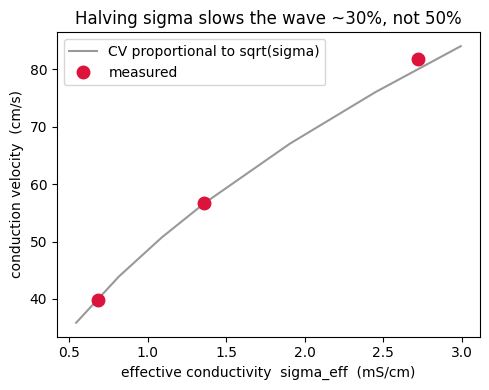

In [4]:
sig = [cond.sigma_eff for cond, _ in results]
cv  = [c for _, c in results]

# the sqrt reference, anchored at the healthy (middle) measurement
base_s, base_cv = sig[1], cv[1]
fine = [base_s * f for f in [0.4, 0.6, 0.8, 1.0, 1.4, 1.8, 2.2]]
ref  = [base_cv * (s / base_s) ** 0.5 for s in fine]

plt.figure(figsize=(5, 4))
plt.plot(fine, ref, "-", color="0.6", label="CV proportional to sqrt(sigma)")
plt.plot(sig, cv, "o", ms=9, color="crimson", label="measured")
plt.xlabel("effective conductivity  sigma_eff  (mS/cm)")
plt.ylabel("conduction velocity  (cm/s)")
plt.title("Halving sigma slows the wave ~30%, not 50%")
plt.legend()
plt.tight_layout()
plt.show()

**What just happened.** Conductivity is the headline speed knob, but it acts through a square root.
That is worth burning in, because it is the number-one way a by-hand tuner over-corrects: if your model
runs 15% too slow, you do **not** raise σ by 15% — you raise it by about 30% (1.15² ≈ 1.32). The √
turns every velocity fix into a *squared* conductivity change.

---
## 2. One number underneath: `D_eff`

Why a square root? Because the wave doesn't feel σ directly. Propagation is a balance between current
*spreading* through the tissue and current *charging up* each membrane it reaches, and that balance is
captured by a single **effective diffusivity**:

```
D_eff = sigma / (chi * Cm)
```

- **σ** (conductivity) — how freely current spreads. Bigger → faster.
- **χ** (chi, the surface-to-volume ratio) — how much membrane area each unit of tissue volume has to
  charge. Bigger → more membrane to fill → slower.
- **Cm** (membrane capacitance) — how much charge each bit of membrane soaks up before its voltage
  moves. Bigger → slower.

Conduction velocity goes as `CV ∝ √D_eff`. The library computes `D_eff` for you — every
`ConductivityConfig` carries it. Notice it is σ that is divided down by χ·Cm:

In [5]:
for k, (cond, cv) in zip(factors, results):
    print(f"sigma x {k:>3}:  D_eff = {cond.D_eff:.3e} cm^2/ms   CV = {cv:.1f} cm/s")

sigma x 0.5:  D_eff = 4.861e-04 cm^2/ms   CV = 39.7 cm/s
sigma x 1.0:  D_eff = 9.722e-04 cm^2/ms   CV = 56.7 cm/s
sigma x 2.0:  D_eff = 1.944e-03 cm^2/ms   CV = 81.9 cm/s


`D_eff` is what the wave actually rides on. Halving σ halves `D_eff` (from 9.7e-4 to 4.9e-4), and
CV follows its square root down. Everything in the rest of this notebook is really a story about moving
this one number.

---
## 3. The denominators — χ and Cm

`D_eff = σ / (χ·Cm)` has σ on top and **χ·Cm on the bottom**. So raising a *denominator* must do the
same thing as lowering σ: slow the wave. `ConductivityConfig` lets you set χ directly (its default is
1400 /cm). Let's double it and see.

In [6]:
g    = cc.Grid(101, 31, 0.01)
stim = cc.Stim.boundary(g, "left", start_time=1.0, duration=2.0, amplitude=-80.0)

# healthy sigma, but chi doubled from its default 1400 to 2800
cond_hi_chi = cc.ConductivityConfig.bidomain(1.74, 6.25, chi=2800.0)
r = cc.monodomain(g, "ttp06", cond_hi_chi, stim, dt=0.1).run(t_end=35.0, save_every=0.5)

print(f"chi = 2800 (doubled):  D_eff = {cond_hi_chi.D_eff:.3e}   CV = {r.cv(20, 70, 15):.1f} cm/s")
print(f"  compare: halving sigma gave                        CV = {results[0][1]:.1f} cm/s")

chi = 2800 (doubled):  D_eff = 4.861e-04   CV = 39.7 cm/s
  compare: halving sigma gave                        CV = 39.7 cm/s


Doubling χ gives **~39.7 cm/s** — the *same* velocity as halving σ. That is no coincidence: both
moves halve `D_eff` (9.7e-4 → 4.9e-4), and the wave only ever sees `D_eff`. Raising Cm would do the
same on the velocity (and additionally stretch the action potential's timescale, since Cm also sets how
fast each cell charges).

---
## 4. The degeneracy — four knobs, one wave

Here is the punchline, and it is the single most useful thing to understand before you start tuning:
**σ, χ, and Cm are not independent.** They enter only through `D_eff = σ/(χ·Cm)`. So if you scale σ
and χ by the *same* factor, `D_eff` is unchanged — and you get the **identical wave**. Watch:

In [7]:
# config A: healthy sigma, default chi
condA = cc.ConductivityConfig.bidomain(1.74,  6.25,  chi=1400.0)
# config B: HALF the sigma AND half the chi -> D_eff = (sigma/2)/(chi/2) is unchanged
condB = cc.ConductivityConfig.bidomain(0.87,  3.125, chi=700.0)

rA = cc.monodomain(g, "ttp06", condA, stim, dt=0.1).run(t_end=35.0, save_every=0.5)
rB = cc.monodomain(g, "ttp06", condB, stim, dt=0.1).run(t_end=35.0, save_every=0.5)

print(f"A  sigma=1.74/6.25  chi=1400 :  D_eff={condA.D_eff:.3e}  CV={rA.cv(20,70,15):.1f} cm/s")
print(f"B  sigma=0.87/3.125 chi= 700 :  D_eff={condB.D_eff:.3e}  CV={rB.cv(20,70,15):.1f} cm/s")

A  sigma=1.74/6.25  chi=1400 :  D_eff=9.722e-04  CV=56.7 cm/s
B  sigma=0.87/3.125 chi= 700 :  D_eff=9.722e-04  CV=56.7 cm/s


Two very different-looking conductivity settings, the **same** `D_eff`, and the **same** conduction
velocity to the decimal. This is why a velocity measurement alone can never tell you σ *and* χ
separately — it only pins down their ratio. If you are hand-tuning a model to hit a target CV, you have
a whole family of (σ, χ, Cm) settings that all land on it; pick the one whose values you actually trust
from the literature, and don't chase the others. (Chapter 2's cell-level knobs are the way to break the
tie, because they change the *shape* of the beat, not just the speed.)

### Try it yourself

1. **Predict, then check.** Add `0.25` to the `factors` list in section 1 and re-run it. Before you
   look, predict the velocity: quarter conductivity means √0.25 = 0.5, so CV should be about *half* the
   healthy value — near 28 cm/s. Is it? (This is the √ law working in your favour: a big σ change for a
   modest speed change.)
2. **Break the degeneracy the wrong way.** In section 4, change `condB` to `bidomain(0.87, 3.125,
   chi=1400.0)` — i.e. halve σ but leave χ alone. Now `D_eff` really is halved, and B should drop to
   ~39.7 cm/s. The degeneracy only holds when σ and χ move *together*.

---
## Recap

- **Conductivity σ sets conduction velocity, but as a square root** (`CV ∝ √σ`): halving σ slows the
  wave ~30%, not 50%. Tune σ by squaring the speed error, not matching it.
- The wave feels a single combined number, **`D_eff = σ / (χ·Cm)`**, and `CV ∝ √D_eff`.
- **χ and Cm are the denominators**: raising either slows the wave exactly as lowering σ does.
- Because they collapse into `D_eff`, **different (σ, χ) settings give the identical wave** — a velocity
  target pins down the ratio, not the individual knobs.

**Where next**: notebook 5.2 leaves speed alone and asks about *shape* — how fibre direction turns a
round wave into an ellipse, how a scar makes it curve and can stop it dead, and how a stimulus that is
too weak or too small never launches a wave at all.